# ¿De qué está hecha la Tierra? De nada que conozcamos.

La Tierra no se parece a ningún meteorito. Ni a los del Sistema Solar interior, ni a los del exterior. ¿Entonces de dónde salió su material? Un equipo analizó 10 anomalías isotópicas en 17 cuerpos del Sistema Solar — y la respuesta es sorprendente.

📄 **Paper:** Render et al. (2026), *Nature Astronomy* — [DOI: 10.1038/s41550-026-02824-7](https://doi.org/10.1038/s41550-026-02824-7)
🔬 **Datos:** [OSF — DH9AK](https://osf.io/dh9ak/)
▶️ **Video:** [Pendiente]

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-15-acrecion-homogenea-tierra-sistema-solar/notebook.ipynb)

## El debate: ¿cuánto material exterior tiene la Tierra?

Los meteoritos se dividen en dos familias según dónde se formaron: **no-carbonáceos** (Sistema Solar interior) y **carbonáceos** (Sistema Solar exterior). Hasta ahora, dos hipótesis competían: la Tierra tiene ~6% de material exterior (poco) o ~40% (mucho). Ninguna usaba todos los sistemas isotópicos a la vez.

Este equipo usó 10 anomalías isotópicas nucleosintéticas (variaciones diminutas en la abundancia de isótopos creados en estrellas, antes de que existiera el Sistema Solar) para mapear la "huella digital" de cada cuerpo. El resultado: la Tierra se formó **exclusivamente** de material del interior.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FUENTE = 'Fuente: Render et al. (2026), Nature Astronomy | Datos: OSF (DH9AK)'

COLOR_CARB = '#DC2626'       # Carbonáceos (SS exterior)
COLOR_NC = '#2563EB'         # No-carbonáceos (SS interior)
COLOR_TIERRA = '#059669'     # Tierra
COLOR_MARTE = '#D97706'      # Marte
COLOR_OTROS = '#7C3AED'      # Ureilitas, Vesta
COLOR_GRIS = '#BBBBBB'       # Contexto

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, urllib.request, re

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'

# Descargar datos si no existen
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)

for fname in ['input_mlr.csv', 'bayesian_fig1.csv']:
    local = f'datos/{fname}'
    if not os.path.exists(local):
        urllib.request.urlretrieve(f'{BASE}/papers/2026-04-15-acrecion-homogenea-tierra-sistema-solar/datos/{fname}', local)

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
df_mlr = pd.read_csv('datos/input_mlr.csv')
df_bay = pd.read_csv('datos/bayesian_fig1.csv', header=None,
                      names=['label', 'value', 'uncertainty'])

# Parsear coordenadas bayesianas
bodies = {}
for _, row in df_bay.iterrows():
    m = re.match(r'Z\[(.+), (\d)\]', row['label'])
    if m:
        body, dim = m.group(1), int(m.group(2))
        if body not in bodies:
            bodies[body] = {}
        bodies[body][f'z{dim}'] = row['value']
        bodies[body][f'z{dim}_unc'] = row['uncertainty']

# Clasificar cuerpos
carbonaceous = ['CI', 'CM', 'CO', 'CV', 'CR']
non_carbonaceous = ['H', 'L', 'LL', 'EH', 'EL']

print(f"Cuerpos con anomalías isotópicas: {len(df_mlr)}")
print(f"  OC-EC: {len(df_mlr[df_mlr['Reservoir']=='OC-EC'])}")
print(f"  Iron Meteorites: {len(df_mlr[df_mlr['Reservoir']=='Iron Meteorites'])}")
print(f"Cuerpos en mapa bayesiano: {len(bodies)}")
print(f"  Carbonáceos: {', '.join(carbonaceous)}")
print(f"  No-carbonáceos: {', '.join(non_carbonaceous)}")
print(f"  Tierra, Marte, Ureilitas, Grupo Vesta")

Cuerpos con anomalías isotópicas: 17
  OC-EC: 9
  Iron Meteorites: 8
Cuerpos en mapa bayesiano: 14
  Carbonáceos: CI, CM, CO, CV, CR
  No-carbonáceos: H, L, LL, EH, EL
  Tierra, Marte, Ureilitas, Grupo Vesta


## El mapa isotópico del Sistema Solar

Míralo.

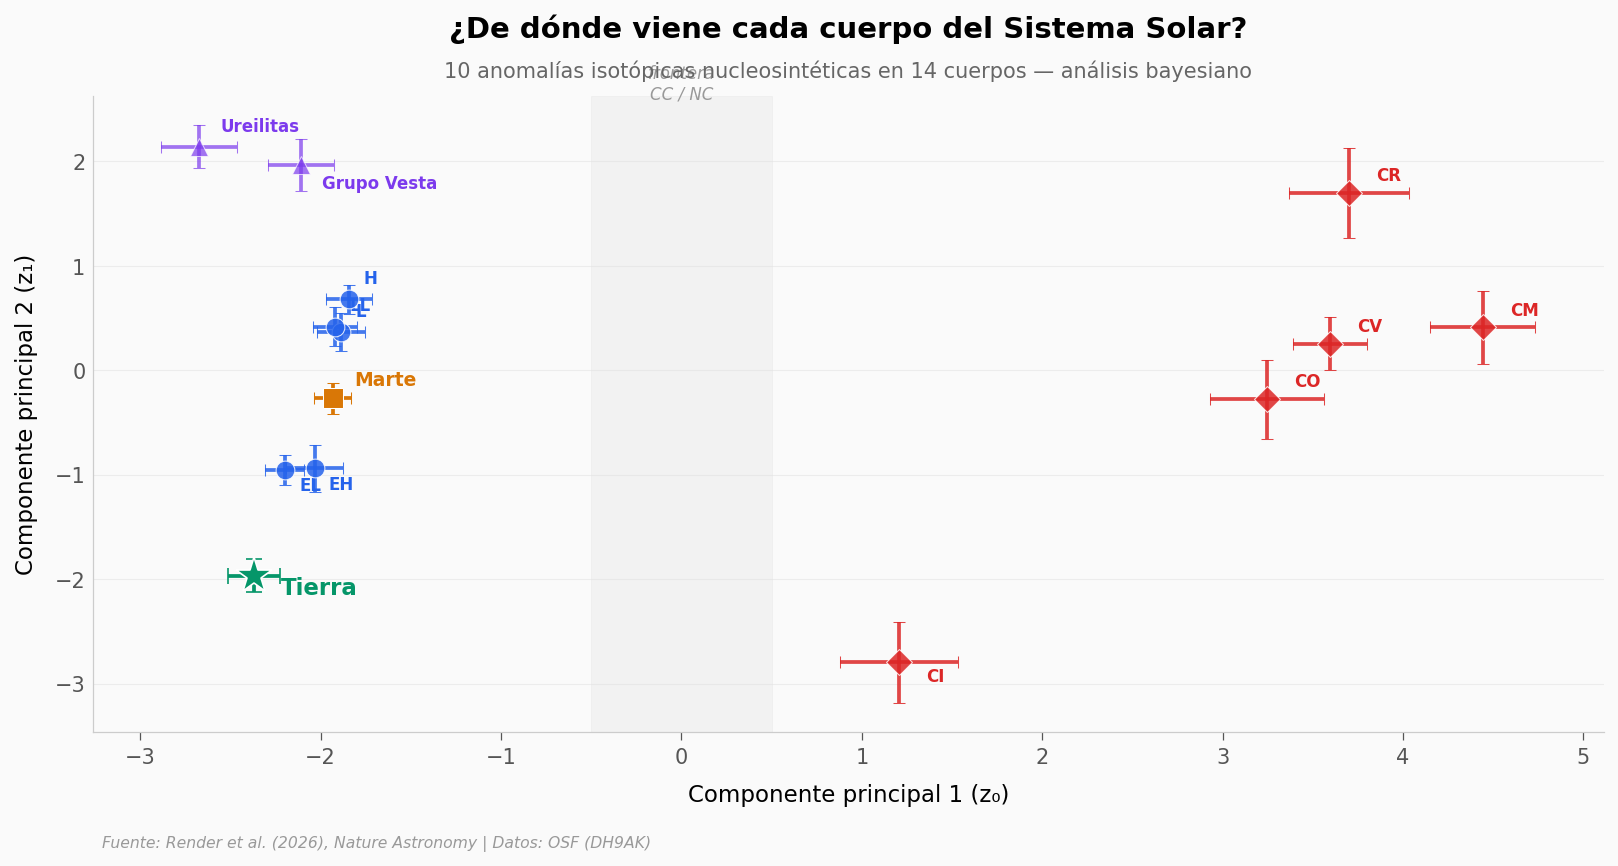

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Carbonáceos
for b in carbonaceous:
    d = bodies[b]
    ax.errorbar(d['z0'], d['z1'], xerr=d['z0_unc'], yerr=d['z1_unc'],
                fmt='D', color=COLOR_CARB, markersize=9, capsize=3,
                markeredgecolor='white', markeredgewidth=0.5, zorder=5, alpha=0.85)
    offset_x = 0.15 if b != 'CR' else 0.15
    offset_y = 0.12 if b not in ['CO', 'CI'] else (-0.18 if b == 'CI' else 0.12)
    ax.text(d['z0'] + offset_x, d['z1'] + offset_y, b,
            fontsize=8, color=COLOR_CARB, fontweight='bold', ha='left')

# No-carbonáceos
for b in non_carbonaceous:
    d = bodies[b]
    ax.errorbar(d['z0'], d['z1'], xerr=d['z0_unc'], yerr=d['z1_unc'],
                fmt='o', color=COLOR_NC, markersize=9, capsize=3,
                markeredgecolor='white', markeredgewidth=0.5, zorder=5, alpha=0.85)
    offset_y = 0.15 if b not in ['EH', 'EL'] else -0.20
    ax.text(d['z0'] + 0.08, d['z1'] + offset_y, b,
            fontsize=8, color=COLOR_NC, fontweight='bold', ha='left')

# Tierra — estrella grande
d = bodies['Earth']
ax.errorbar(d['z0'], d['z1'], xerr=d['z0_unc'], yerr=d['z1_unc'],
            fmt='*', color=COLOR_TIERRA, markersize=18, capsize=4,
            markeredgecolor='white', markeredgewidth=0.8, zorder=10)
ax.text(d['z0'] + 0.15, d['z1'] - 0.18, 'Tierra',
        fontsize=11, color=COLOR_TIERRA, fontweight='bold')

# Marte
d = bodies['Mars']
ax.errorbar(d['z0'], d['z1'], xerr=d['z0_unc'], yerr=d['z1_unc'],
            fmt='s', color=COLOR_MARTE, markersize=10, capsize=3,
            markeredgecolor='white', markeredgewidth=0.5, zorder=7)
ax.text(d['z0'] + 0.12, d['z1'] + 0.12, 'Marte',
        fontsize=9, color=COLOR_MARTE, fontweight='bold')

# Ureilitas y Vesta
for b, label in [('Ureilites', 'Ureilitas'), ('Vesta Group', 'Grupo Vesta')]:
    d = bodies[b]
    ax.errorbar(d['z0'], d['z1'], xerr=d['z0_unc'], yerr=d['z1_unc'],
                fmt='^', color=COLOR_OTROS, markersize=9, capsize=3,
                markeredgecolor='white', markeredgewidth=0.5, zorder=5, alpha=0.7)
    oy = 0.15 if b == 'Ureilites' else -0.22
    ax.text(d['z0'] + 0.12, d['z1'] + oy, label,
            fontsize=8, color=COLOR_OTROS, fontweight='bold')

# Zona divisoria CC/NC (franja vertical sutil)
ax.axvspan(-0.5, 0.5, alpha=0.06, color='gray')
ax.text(0, 2.6, 'frontera\nCC / NC', fontsize=8, color='#999999',
        ha='center', style='italic')

ax.set_xlabel('Componente principal 1 (z₀)', fontsize=11)
ax.set_ylabel('Componente principal 2 (z₁)', fontsize=11)
ax.set_title('¿De dónde viene cada cuerpo del Sistema Solar?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '10 anomalías isotópicas nucleosintéticas en 14 cuerpos — análisis bayesiano',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mapa_isotopico_sistema_solar.png', dpi=200, bbox_inches='tight')
plt.show()

## La dicotomía del Sistema Solar

Dos mundos isotópicos. A la derecha (z₀ positivo), los carbonáceos: CI, CM, CO, CV, CR — formados más allá de la órbita de Júpiter. A la izquierda, los no-carbonáceos: H, L, LL, EH, EL — nacidos en el Sistema Solar interior.

Pero mira dónde cae la Tierra: **no está entre los no-carbonáceos, sino MÁS ALLÁ.** Es el punto más extremo del lado interior. z₀ = −2,37 cuando el no-carbonáceo más extremo (EL) llega a −2,20. La Tierra no es una mezcla de ambos lados — es un endmember puro del lado interior.

Marte cae cómodamente dentro del grupo no-carbonáceo. Ureilitas y el Grupo Vesta están en el lado interior pero con z₁ alto — misma familia, receta diferente.

## Las huellas isotópicas individuales

¿Cómo se ve cada anomalía isotópica por separado?

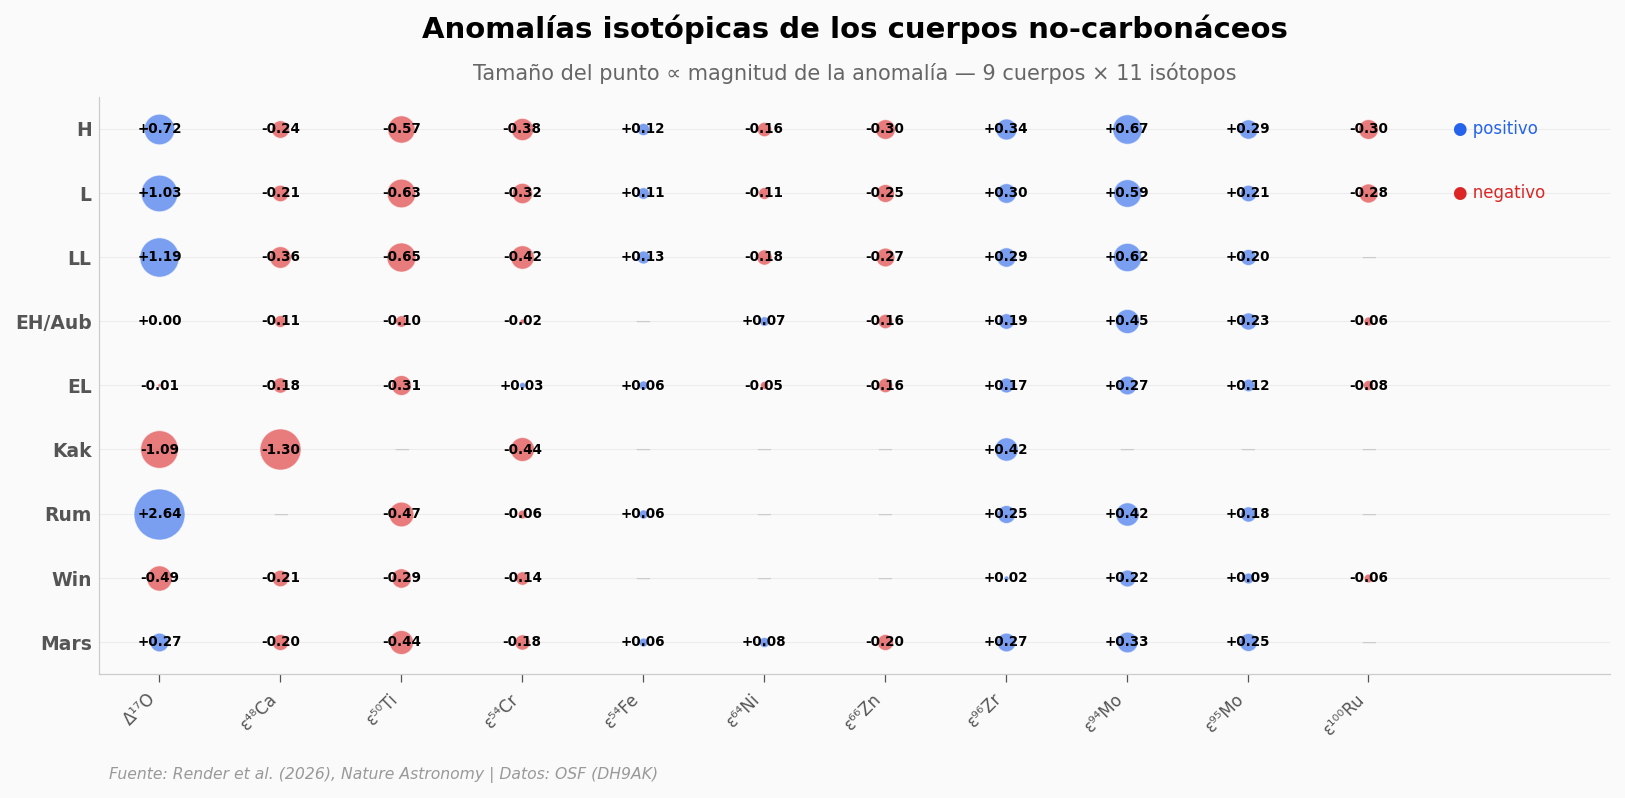

In [3]:
isotopes = ['17O', '48Ca', '50Ti', '54Cr', '54Fe', '64Ni', '66Zn',
            '96Zr', '94Mo', '95Mo', '100Ru']

# Preparar datos: solo OC-EC bodies para el heatmap
oc_ec = df_mlr[df_mlr['Reservoir'] == 'OC-EC'].copy()
oc_ec = oc_ec.set_index('Chondrites')

fig, ax = plt.subplots(figsize=(13, 5))

# Heatmap manual con scatter — tamaño = 1/incertidumbre (más grande = más preciso)
for i, body in enumerate(oc_ec.index):
    for j, iso in enumerate(isotopes):
        val = oc_ec.loc[body, iso]
        unc = oc_ec.loc[body, f'{iso}_uncertainty']
        if pd.isna(val):
            ax.text(j, i, '—', ha='center', va='center', fontsize=7, color='#CCCCCC')
            continue
        # Color: azul si positivo, rojo si negativo
        color = COLOR_NC if val >= 0 else COLOR_CARB
        # Tamaño proporcional al valor absoluto
        size = min(abs(val) * 300, 600)
        ax.scatter(j, i, s=size, color=color, alpha=0.6,
                   edgecolors='white', linewidths=0.5, zorder=5)
        # Valor numérico
        ax.text(j, i, f'{val:+.2f}', ha='center', va='center',
                fontsize=6.5, color='black', fontweight='bold', zorder=6)

ax.set_xticks(range(len(isotopes)))
iso_labels = ['Δ¹⁷O', 'ε⁴⁸Ca', 'ε⁵⁰Ti', 'ε⁵⁴Cr', 'ε⁵⁴Fe', 'ε⁶⁴Ni',
              'ε⁶⁶Zn', 'ε⁹⁶Zr', 'ε⁹⁴Mo', 'ε⁹⁵Mo', 'ε¹⁰⁰Ru']
ax.set_xticklabels(iso_labels, fontsize=8, rotation=45, ha='right')
ax.set_yticks(range(len(oc_ec.index)))
ax.set_yticklabels(oc_ec.index, fontsize=9, fontweight='bold')

# Leyenda inline
ax.text(10.7, 0, '● positivo', fontsize=8, color=COLOR_NC, va='center')
ax.text(10.7, 1, '● negativo', fontsize=8, color=COLOR_CARB, va='center')

ax.set_title('Anomalías isotópicas de los cuerpos no-carbonáceos',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Tamaño del punto ∝ magnitud de la anomalía — 9 cuerpos × 11 isótopos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlim(-0.5, 12)
ax.set_ylim(-0.5, len(oc_ec.index) - 0.5)
ax.invert_yaxis()

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalias_isotopicas_nc.png', dpi=200, bbox_inches='tight')
plt.show()

## La Tierra como extremo del gradiente

El dato clave: si trazas una línea recta a través de los cuerpos no-carbonáceos y la extiendes, pasa por la Tierra — dentro de 1 desviación estándar, en TODOS los pares de isótopos.

Regresión NC array: pendiente = 5.046, r = 0.909, p = 0.0323
Residual Tierra (z₁): 0.110
Incertidumbre Tierra z₁: ±0.156
¿Dentro de 1 SD? True


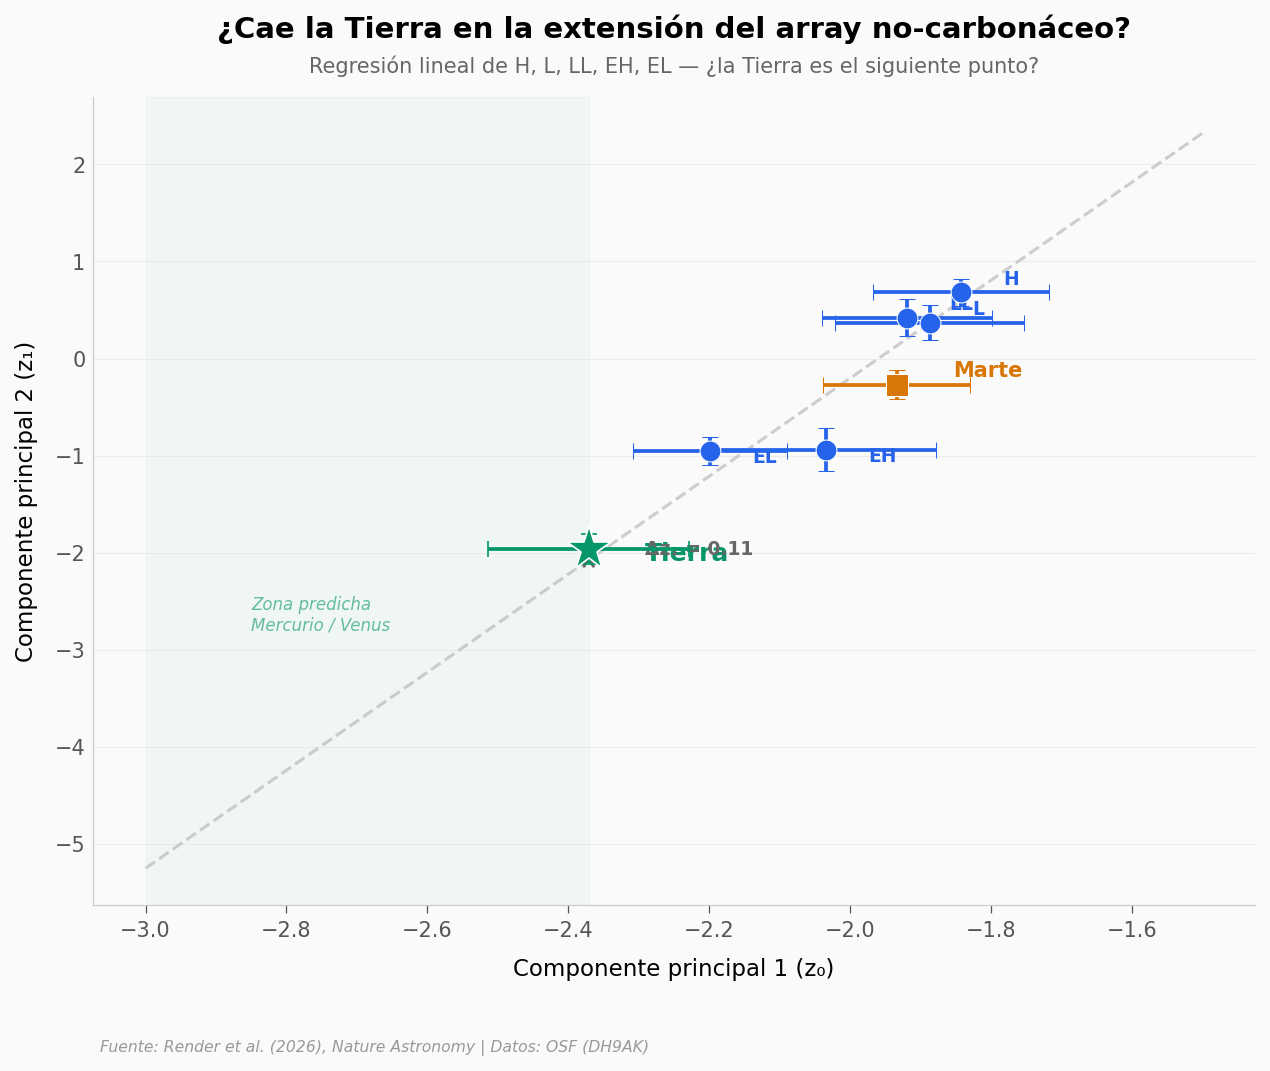

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))

# Datos NC para regresión
nc_z0 = np.array([bodies[b]['z0'] for b in non_carbonaceous])
nc_z1 = np.array([bodies[b]['z1'] for b in non_carbonaceous])

# Regresión lineal del array NC
slope, intercept, r_value, p_value, std_err = __import__('scipy').stats.linregress(nc_z0, nc_z1)

# Extensión del array NC (línea más allá del rango)
x_ext = np.linspace(-3.0, -1.5, 100)
y_ext = slope * x_ext + intercept

# Línea de extensión
ax.plot(x_ext, y_ext, '--', color=COLOR_GRIS, linewidth=1.5, alpha=0.7, zorder=2,
        label=f'Extensión array NC (r = {r_value:.3f})')

# NC bodies
for b in non_carbonaceous:
    d = bodies[b]
    ax.errorbar(d['z0'], d['z1'], xerr=d['z0_unc'], yerr=d['z1_unc'],
                fmt='o', color=COLOR_NC, markersize=10, capsize=4,
                markeredgecolor='white', markeredgewidth=0.5, zorder=5)
    oy = 0.08 if b not in ['EH', 'EL'] else -0.12
    ax.text(d['z0'] + 0.06, d['z1'] + oy, b,
            fontsize=9, color=COLOR_NC, fontweight='bold')

# Tierra
d = bodies['Earth']
ax.errorbar(d['z0'], d['z1'], xerr=d['z0_unc'], yerr=d['z1_unc'],
            fmt='*', color=COLOR_TIERRA, markersize=22, capsize=4,
            markeredgecolor='white', markeredgewidth=0.8, zorder=10)
ax.text(d['z0'] + 0.08, d['z1'] - 0.12, 'Tierra',
        fontsize=12, color=COLOR_TIERRA, fontweight='bold')

# Marte
d = bodies['Mars']
ax.errorbar(d['z0'], d['z1'], xerr=d['z0_unc'], yerr=d['z1_unc'],
            fmt='s', color=COLOR_MARTE, markersize=11, capsize=4,
            markeredgecolor='white', markeredgewidth=0.5, zorder=7)
ax.text(d['z0'] + 0.08, d['z1'] + 0.08, 'Marte',
        fontsize=10, color=COLOR_MARTE, fontweight='bold')

# Valor predicho de la Tierra por la extensión del array NC
earth_pred_z1 = slope * d['z0'] + intercept
earth_z0_val = bodies['Earth']['z0']
earth_pred_on_line = slope * earth_z0_val + intercept

# Distancia de la Tierra a la línea (en z1)
residual = bodies['Earth']['z1'] - earth_pred_on_line
ax.annotate('', xy=(earth_z0_val, bodies['Earth']['z1']),
            xytext=(earth_z0_val, earth_pred_on_line),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(earth_z0_val + 0.08, (bodies['Earth']['z1'] + earth_pred_on_line) / 2,
        f'Δz₁ = {abs(residual):.2f}',
        fontsize=9, color='#666666', fontweight='bold')

# Predicción: zona donde estarían Mercury y Venus (más extremo que Earth)
ax.axvspan(-3.0, earth_z0_val, alpha=0.04, color=COLOR_TIERRA)
ax.text(-2.85, -2.8, 'Zona predicha\nMercurio / Venus',
        fontsize=8, color=COLOR_TIERRA, alpha=0.6, style='italic')

ax.set_xlabel('Componente principal 1 (z₀)', fontsize=11)
ax.set_ylabel('Componente principal 2 (z₁)', fontsize=11)
ax.set_title('¿Cae la Tierra en la extensión del array no-carbonáceo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Regresión lineal de H, L, LL, EH, EL — ¿la Tierra es el siguiente punto?',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

print(f"Regresión NC array: pendiente = {slope:.3f}, r = {r_value:.3f}, p = {p_value:.4f}")
print(f"Residual Tierra (z₁): {residual:.3f}")
print(f"Incertidumbre Tierra z₁: ±{bodies['Earth']['z1_unc']:.3f}")
print(f"¿Dentro de 1 SD? {abs(residual) <= bodies['Earth']['z1_unc']}")

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/extension_array_nc.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan lejos está la Tierra del resto?

La Tierra es el punto más extremo de todos los no-carbonáceos en z₁ — y por un margen que no es sutil.

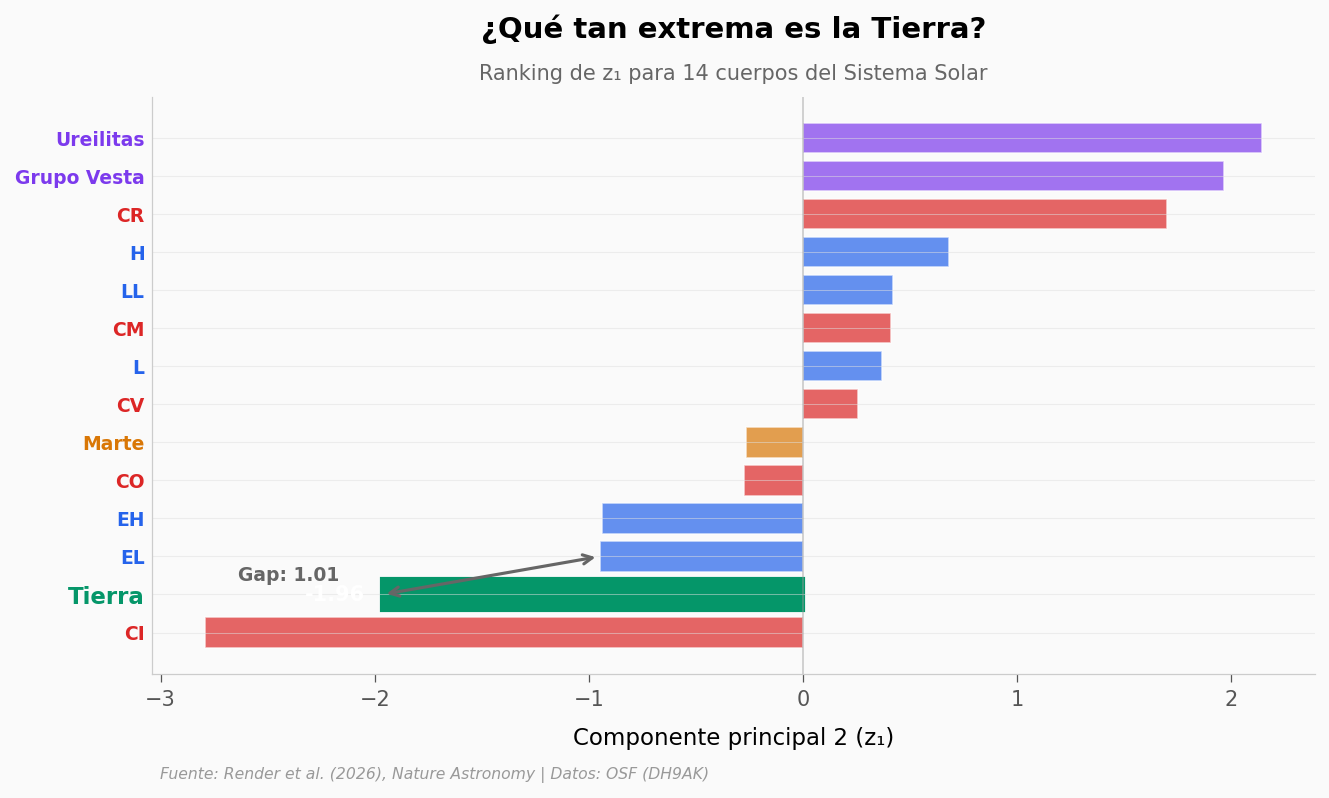

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# z1 de todos los cuerpos
all_bodies_list = carbonaceous + non_carbonaceous + ['Earth', 'Mars', 'Ureilites', 'Vesta Group']
all_z1 = [bodies[b]['z1'] for b in all_bodies_list]
label_map = {'Earth': 'Tierra', 'Mars': 'Marte', 'Ureilites': 'Ureilitas', 'Vesta Group': 'Grupo Vesta'}
all_labels = [label_map.get(b, b) for b in all_bodies_list]

# Colores por tipo
colors = ([COLOR_CARB] * len(carbonaceous) +
          [COLOR_NC] * len(non_carbonaceous) +
          [COLOR_TIERRA, COLOR_MARTE, COLOR_OTROS, COLOR_OTROS])

# Ordenar por z1
order = np.argsort(all_z1)
sorted_z1 = [all_z1[i] for i in order]
sorted_labels = [all_labels[i] for i in order]
sorted_colors = [colors[i] for i in order]

# Bar chart horizontal
bars = ax.barh(range(len(sorted_z1)), sorted_z1, color=sorted_colors, alpha=0.7,
               edgecolor='white', linewidth=0.8)
ax.set_yticks(range(len(sorted_labels)))
ax.set_yticklabels(sorted_labels, fontsize=9, fontweight='bold')

# Colorear etiquetas
for tick, color in zip(ax.get_yticklabels(), sorted_colors):
    tick.set_color(color)

# Tierra — highlight
earth_idx = sorted_labels.index('Tierra')
bars[earth_idx].set_color(COLOR_TIERRA)
bars[earth_idx].set_alpha(1.0)
bars[earth_idx].set_edgecolor(COLOR_TIERRA)
bars[earth_idx].set_linewidth(2)
ax.get_yticklabels()[earth_idx].set_color(COLOR_TIERRA)
ax.get_yticklabels()[earth_idx].set_fontsize(11)

# Valor de la Tierra
earth_z1 = bodies['Earth']['z1']
ax.text(earth_z1 - 0.08, earth_idx, f'{earth_z1:.2f}',
        fontsize=10, color='white', fontweight='bold', ha='right', va='center')

# Línea de referencia: z1 = 0
ax.axvline(x=0, color='#999999', linewidth=0.8, linestyle='-', alpha=0.5)

# Flecha del gap
nc_min_z1 = min(bodies[b]['z1'] for b in non_carbonaceous)
nc_min_body = [b for b in non_carbonaceous if bodies[b]['z1'] == nc_min_z1][0]
nc_min_idx = sorted_labels.index(nc_min_body)
ax.annotate('', xy=(earth_z1, earth_idx), xytext=(nc_min_z1, nc_min_idx),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
gap = abs(earth_z1 - nc_min_z1)
mid_y = (earth_idx + nc_min_idx) / 2
ax.text(min(earth_z1, nc_min_z1) - 0.2, mid_y,
        f'Gap: {gap:.2f}', fontsize=9, color='#666666', fontweight='bold',
        ha='right', va='center')

ax.set_xlabel('Componente principal 2 (z₁)', fontsize=11)
ax.set_title('¿Qué tan extrema es la Tierra?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Ranking de z₁ para 14 cuerpos del Sistema Solar',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ranking_z1_tierra.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La Tierra se formó exclusivamente de material del Sistema Solar interior | ✅ | z₀ = −2,37 y z₁ = −1,96 — la Tierra es el endmember del array NC. La extensión lineal del array NC pasa por la Tierra dentro de 1 SD |
| Existe una dicotomía clara CC vs NC en el Sistema Solar | ✅ | Gap de ~3 unidades en z₀ entre el carbonáceo más cercano (CI, z₀ = +1,21) y el no-carbonáceo más lejano (H, z₀ = −1,84) |
| Mercurio y Venus tendrían composiciones más extremas que la Tierra | ⚠️ | Es una predicción del modelo (extrapolación del array NC más allá de la Tierra). No hay datos isotópicos directos de Mercurio o Venus para verificar |
| La composición de la Tierra no coincide con ninguna condrita conocida | ✅ | La Tierra (z₀ = −2,37) está fuera del rango de todas las condritas NC (z₀ de −2,20 a −1,84). Su composición es, en promedio, diferente de cualquier meteorito |
| Marte se formó de material del Sistema Solar interior | ✅ | z₀ = −1,93 — Marte cae dentro del rango de condritas NC (entre LL y EH) |

> **Limitaciones:** (1) El análisis bayesiano asume relaciones lineales entre anomalías isotópicas — la realidad podría tener no-linealidades. (2) La predicción para Mercurio y Venus es una extrapolación sin verificación posible actualmente. (3) El análisis usa composición isotópica de la Tierra silicatada (BSE), no la Tierra completa incluyendo el núcleo. (4) Los datos provienen de 14 cuerpos — una muestra limitada del Sistema Solar.

## Ahora tú

1. **¿Qué isótopo separa mejor CC de NC?** Filtra `df_mlr` por `Reservoir` y compara las medias por isótopo. ¿Cuál tiene el ratio señal/ruido más alto?

2. **¿Cuánto material carbonáceo tolera el modelo?** Modifica la posición de la Tierra mezclando un % de CI con la composición NC media. ¿A partir de qué porcentaje la Tierra sale del array NC?

3. **¿Dónde caería la Luna?** La Luna tiene anomalías isotópicas casi idénticas a la Tierra (Δ¹⁷O ≈ 0, ε⁵⁰Ti ≈ −0,5). ¿Dónde la pondrías en el mapa?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánto material carbonáceo puede tener la Tierra?
# Mezclamos composición NC media con CI y vemos cuándo sale del array

nc_mean_z0 = np.mean([bodies[b]['z0'] for b in non_carbonaceous])
nc_mean_z1 = np.mean([bodies[b]['z1'] for b in non_carbonaceous])
ci_z0 = bodies['CI']['z0']
ci_z1 = bodies['CI']['z1']
earth_z0 = bodies['Earth']['z0']
earth_z1 = bodies['Earth']['z1']
earth_unc_z0 = bodies['Earth']['z0_unc']

print("Mezcla NC media + CI (carbonáceo):")
print(f"  NC media: z₀ = {nc_mean_z0:.3f}")
print(f"  CI:       z₀ = {ci_z0:.3f}")
print(f"  Tierra:   z₀ = {earth_z0:.3f} ± {earth_unc_z0:.3f}")
print()

for pct_ci in [0, 5, 10, 20, 30, 40]:
    mix_z0 = (1 - pct_ci/100) * nc_mean_z0 + (pct_ci/100) * ci_z0
    dist_to_earth = abs(mix_z0 - earth_z0)
    within_1sd = dist_to_earth <= earth_unc_z0
    print(f"  {pct_ci:2d}% CI → z₀ = {mix_z0:+.3f}  |  Δ vs Tierra = {dist_to_earth:.3f}  |  {'✅ dentro 1 SD' if within_1sd else '❌ fuera 1 SD'}")

Mezcla NC media + CI (carbonáceo):
  NC media: z₀ = -1.976
  CI:       z₀ = 1.206
  Tierra:   z₀ = -2.371 ± 0.143

   0% CI → z₀ = -1.976  |  Δ vs Tierra = 0.395  |  ❌ fuera 1 SD
   5% CI → z₀ = -1.817  |  Δ vs Tierra = 0.554  |  ❌ fuera 1 SD
  10% CI → z₀ = -1.658  |  Δ vs Tierra = 0.713  |  ❌ fuera 1 SD
  20% CI → z₀ = -1.340  |  Δ vs Tierra = 1.031  |  ❌ fuera 1 SD
  30% CI → z₀ = -1.022  |  Δ vs Tierra = 1.349  |  ❌ fuera 1 SD
  40% CI → z₀ = -0.703  |  Δ vs Tierra = 1.668  |  ❌ fuera 1 SD


---

## Créditos

- **Paper:** Render et al. (2026). *Homogeneous accretion of the Earth in the inner Solar System*. Nature Astronomy. [DOI: 10.1038/s41550-026-02824-7](https://doi.org/10.1038/s41550-026-02824-7)
- **Datos:** [OSF — DH9AK](https://osf.io/dh9ak/) (CC-BY 4.0)
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://cienciaamordiscos.com)
- **Repo:** [GitHub](https://github.com/Ciencia-a-Mordiscos/lab)